<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 10px;">
    <h1 style="color:#e2b96f; font-family:'Segoe UI', sans-serif; font-size:2.2em; margin:0 0 8px 0;">
        🎓 Introdução ao Aprendizado de Máquina
    </h1>
    <h2 style="color:#a8d8ea; font-family:'Segoe UI', sans-serif; font-size:1.3em; margin:0 0 6px 0; font-weight:400;">
        Aula 05 — Regressão Logística
    </h2>
    <h3 style="color:#e2b96f; font-family:'Segoe UI', sans-serif; font-size:1.05em; margin:0 0 12px 0; font-weight:500;">
        🔬 Prática — Probabilidades, Sigmoid e Segundo Modelo no Titanic
    </h3>
    <p style="color:#ccc; font-family:'Segoe UI', sans-serif; font-size:0.9em; margin:0;">
        Prof. Felipe Amaral
    </p>
</div>
<div style="display:flex; gap:10px; margin-top:10px; flex-wrap:wrap;">
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">📚 FIAP</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">🐍 Python 3</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">🚢 Dataset Titanic</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">📈 2º Modelo do Curso</span>
</div>


## Onde estamos?

Na aula anterior treinamos o KNN — nosso primeiro modelo.
Hoje apresentamos o **segundo algoritmo do curso: Regressão Logística**.

Apesar do nome "regressão", ela é um **algoritmo de classificação** — e traz algo que o KNN não conseguia fazer diretamente:

> *Em vez de só dizer "sobreviveu ou não", a Regressão Logística diz:*
> *"Esse passageiro tem **74% de chance** de ter sobrevivido."*

Essa capacidade de produzir **probabilidades** é o que torna o algoritmo poderoso e interpretável.
E há mais: ao contrário do KNN, que é uma "caixa-preta" que apenas busca vizinhos,
a Regressão Logística nos deixa **ler o que o modelo aprendeu** — quais features mais influenciam a sobrevivência, e em qual direção.

---

## Roteiro de hoje

| Parte | Tema | Conceito novo |
|-------|------|---------------|
| **1** | Por que não usar regressão linear? | O problema da saída fora de [0,1] |
| **2** | A função sigmoide | Transformar qualquer número em probabilidade |
| **3** | Segundo modelo | `predict_proba` — saída em probabilidade |
| **4** | Coeficientes | Ler o que o modelo aprendeu |
| **5** | Limiar de decisão | Quando 0,5 não é o melhor corte |
| **6** | KNN vs Reg. Logística | Comparação direta com curva ROC |

> **Tempo estimado: 30 minutos**

<div style="background:#d1ecf1; border-left:5px solid #0c5460; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#0c5460;">Dica de uso profissional:</strong>
<span style="color:#0c5460;"> A Regressão Logística é frequentemente usada como <strong>baseline</strong> em projetos reais. Se um modelo complexo não a superar por uma margem relevante, geralmente não vale a complexidade extra.</span>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize":  (10, 5),
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":     13,
    "axes.labelsize":     11,
})
sns.set_theme(style="whitegrid", palette="muted")

# ── Reproduzindo todo o pré-processamento das aulas anteriores ────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df_raw = sns.load_dataset("titanic")
df = df_raw.copy()

df["age"]      = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df = df.drop(columns=["deck"]).drop_duplicates().reset_index(drop=True)

df["tamanho_familia"]  = df["sibsp"] + df["parch"] + 1
df["sozinho"]          = (df["tamanho_familia"] == 1).astype(int)
df["faixa_etaria_enc"] = pd.cut(df["age"], bins=[0,12,18,60,100],
                                 labels=[0,1,2,3]).astype(int)
df["tarifa_por_pessoa"]= (df["fare"] / df["tamanho_familia"].clip(lower=1)).round(2)
df["sex_enc"]          = (df["sex"] == "female").astype(int)
df["pclass_enc"]       = df["pclass"].map({1:2, 2:1, 3:0})

embarked_ohe = pd.get_dummies(df["embarked"], prefix="embarked", drop_first=True)
df = pd.concat([df, embarked_ohe], axis=1)

FEATURES = ["pclass_enc","sex_enc","age","tamanho_familia","sozinho",
            "faixa_etaria_enc","tarifa_por_pessoa","embarked_q","embarked_s",
            "titulo_Master","titulo_Miss","titulo_Mr","titulo_Mrs","titulo_Raro"]
FEATURES = [f for f in FEATURES if f in df.columns]

X = df[FEATURES].copy()
y = df["survived"].copy()

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_treino_sc = scaler.fit_transform(X_treino)
X_teste_sc  = scaler.transform(X_teste)

# Mantendo o melhor KNN da aula anterior para comparação no final
from sklearn.neighbors import KNeighborsClassifier
knn_ref = KNeighborsClassifier(n_neighbors=7)
knn_ref.fit(X_treino_sc, y_treino)

print("✅ Dataset e KNN de referência prontos!")
print(f"   Treino:  {X_treino_sc.shape[0]} amostras | {X_treino_sc.shape[1]} features")
print(f"   Teste:   {X_teste_sc.shape[0]}  amostras")
print(f"   KNN (K=7) acurácia no teste: {knn_ref.score(X_teste_sc, y_teste):.1%}")


✅ Dataset e KNN de referência prontos!
   Treino:  620 amostras | 7 features
   Teste:   155  amostras
   KNN (K=7) acurácia no teste: 80.6%


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 1</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Por Que Não Usar Regressão Linear para Classificar?</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"O problema não é a matemática — é o que a saída representa."</p>
    </div>
</div>

### O problema concreto

A Regressão **Linear** produz uma reta que prevê um número contínuo:
```
ŷ = β₀ + β₁·x₁ + β₂·x₂ + ...    → ŷ pode ser qualquer número: -∞ a +∞
```

Se tentarmos usá-la para classificação (prever 0 ou 1), dois problemas aparecem imediatamente:

**Problema 1 — A saída sai de [0, 1]**
O modelo pode prever 1.8 ou -0.3. O que significa "probabilidade de 180%"?

**Problema 2 — A reta força linearidade onde não existe**
A chance de sobreviver não cresce indefinidamente com a tarifa — há um teto natural em 100% e um piso em 0%.

**A solução: a função sigmoide**
A Regressão Logística aplica uma transformação na saída linear que garante o resultado sempre entre 0 e 1.
O gráfico abaixo mostra lado a lado o problema e a solução.


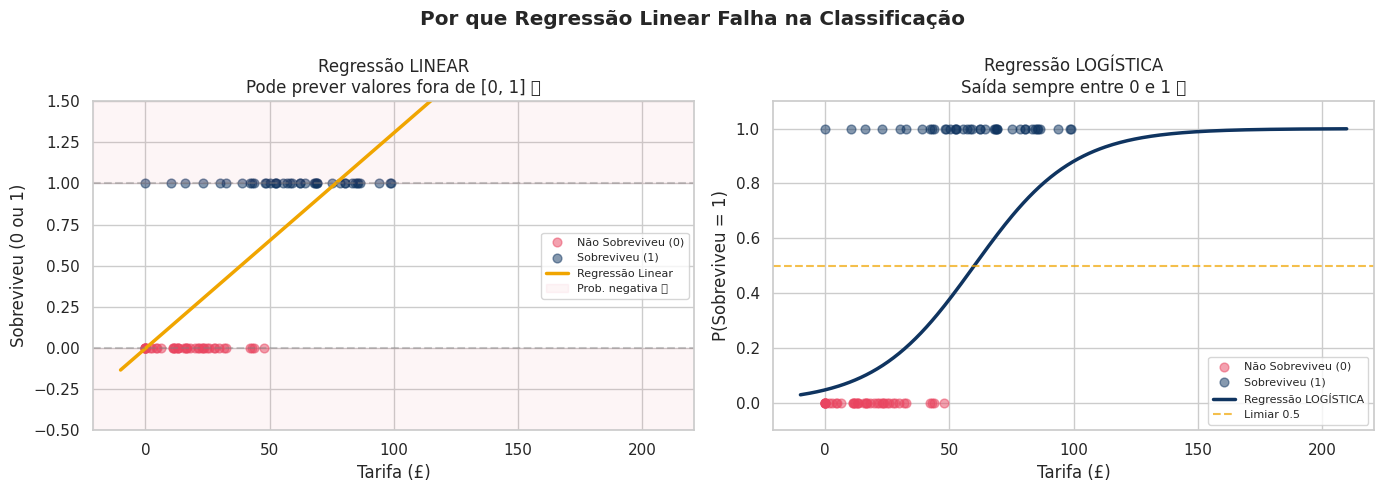

Observe:
  Linear: pode prever -0.2 ou 1.4 — sem sentido como probabilidade
  Logística: sempre entre 0 e 1 — interpretável como probabilidade


In [2]:
# Demonstrando o problema da regressão linear para classificação
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulando: tarifa paga vs sobrevivência (binário)
n = 80
tarifas_nao_sobrev = np.random.normal(20, 15, n//2).clip(0, 100)
tarifas_sobrev     = np.random.normal(60, 25, n//2).clip(0, 200)
tarifas = np.concatenate([tarifas_nao_sobrev, tarifas_sobrev]).reshape(-1, 1)
labels  = np.array([0]*(n//2) + [1]*(n//2))

# Ajustando regressão LINEAR
lr_linear = LinearRegression()
lr_linear.fit(tarifas, labels)

x_plot = np.linspace(-10, 210, 300).reshape(-1, 1)
y_linear = lr_linear.predict(x_plot)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Por que Regressão Linear Falha na Classificação", fontweight="bold")

# Gráfico 1: problema da regressão linear
ax1.scatter(tarifas_nao_sobrev, np.zeros(n//2), color="#e94560",
            alpha=0.5, s=40, label="Não Sobreviveu (0)")
ax1.scatter(tarifas_sobrev, np.ones(n//2), color="#0f3460",
            alpha=0.5, s=40, label="Sobreviveu (1)")
ax1.plot(x_plot, y_linear, color="#f0a500", linewidth=2.5, label="Regressão Linear")
ax1.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax1.axhline(1, color="gray", linestyle="--", alpha=0.4)
ax1.axhspan(-0.5, 0, alpha=0.05, color="#e94560", label="Prob. negativa ❌")
ax1.axhspan(1, 1.5, alpha=0.05, color="#e94560")
ax1.set_xlabel("Tarifa (£)")
ax1.set_ylabel("Sobreviveu (0 ou 1)")
ax1.set_title("Regressão LINEAR\nPode prever valores fora de [0, 1] ❌")
ax1.set_ylim(-0.5, 1.5)
ax1.legend(fontsize=8)

# Gráfico 2: o que queremos — probabilidade entre 0 e 1
from scipy.special import expit as sigmoid
beta0, beta1 = -3.0, 0.05
x_vals = np.linspace(-10, 210, 300)
y_logit = sigmoid(beta0 + beta1 * x_vals)

ax2.scatter(tarifas_nao_sobrev, np.zeros(n//2), color="#e94560",
            alpha=0.5, s=40, label="Não Sobreviveu (0)")
ax2.scatter(tarifas_sobrev, np.ones(n//2), color="#0f3460",
            alpha=0.5, s=40, label="Sobreviveu (1)")
ax2.plot(x_vals, y_logit, color="#0f3460", linewidth=2.5,
         label="Regressão LOGÍSTICA")
ax2.axhline(0.5, color="#f0a500", linestyle="--", alpha=0.7, label="Limiar 0.5")
ax2.set_xlabel("Tarifa (£)")
ax2.set_ylabel("P(Sobreviveu = 1)")
ax2.set_title("Regressão LOGÍSTICA\nSaída sempre entre 0 e 1 ✅")
ax2.set_ylim(-0.1, 1.1)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("aula06_linear_vs_logistica.png", dpi=110, bbox_inches="tight")
plt.show()

print("Observe:")
print("  Linear: pode prever -0.2 ou 1.4 — sem sentido como probabilidade")
print("  Logística: sempre entre 0 e 1 — interpretável como probabilidade")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 2</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">A Função Sigmoide — O Coração da Regressão Logística</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Uma função elegante que transforma qualquer número em uma probabilidade."</p>
    </div>
</div>

### A equação em duas partes

```
         1
P(Y=1) = ─────────────────────────────────
         1 + e^−z       onde  z = β₀ + β₁·X₁ + β₂·X₂ + ...
```

**Parte 1 — a combinação linear** (igual à regressão linear):
```
z = β₀ + β₁·X₁ + β₂·X₂ + ...    → z pode ser qualquer número
```

**Parte 2 — a sigmoide** transforma z em probabilidade:
```
         1
σ(z) = ──────    →  resultado sempre entre 0 e 1
       1 + e^−z
```

| z muito negativo | z = 0 | z muito positivo |
|------------------|-------|-----------------|
| P ≈ 0 (não sobreviveu) | P = 0,5 (50/50) | P ≈ 1 (sobreviveu) |

O gráfico abaixo mostra a curva e o efeito do coeficiente β₁ na inclinação.


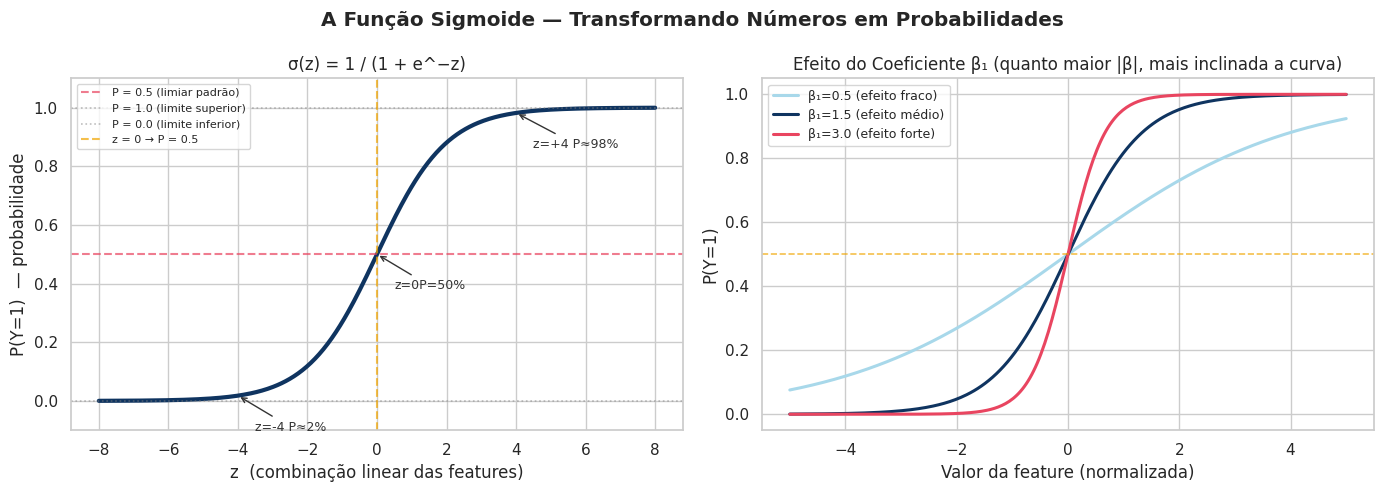

In [3]:
# Visualizando a função sigmoide
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-8, 8, 400)
sigmoid = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("A Função Sigmoide — Transformando Números em Probabilidades",
             fontweight="bold")

# Gráfico 1: a sigmoide básica
ax = axes[0]
ax.plot(z, sigmoid, color="#0f3460", linewidth=3)
ax.axhline(0.5, color="#e94560", linestyle="--", linewidth=1.5, alpha=0.7,
           label="P = 0.5 (limiar padrão)")
ax.axhline(1.0, color="gray",    linestyle=":", linewidth=1.2, alpha=0.5,
           label="P = 1.0 (limite superior)")
ax.axhline(0.0, color="gray",    linestyle=":", linewidth=1.2, alpha=0.5,
           label="P = 0.0 (limite inferior)")
ax.axvline(0.0, color="#f0a500", linestyle="--", linewidth=1.5, alpha=0.7,
           label="z = 0 → P = 0.5")

# Anotando pontos especiais
for z_val, p_val, txt in [(-4, sigmoid[-300], "z=-4 P≈2%"), (0, 0.5, "z=0P=50%"), (4, sigmoid[300], "z=+4 P≈98%")]:
    ax.annotate(txt, xy=(z_val, 1/(1+np.exp(-z_val))),
                xytext=(z_val + 0.5, 1/(1+np.exp(-z_val)) - 0.12),
                fontsize=9, color="#333",
                arrowprops=dict(arrowstyle="->", color="#333", lw=1))

ax.set_xlabel("z  (combinação linear das features)")
ax.set_ylabel("P(Y=1)  — probabilidade")
ax.set_title("σ(z) = 1 / (1 + e^−z)")
ax.legend(fontsize=8)
ax.set_ylim(-0.1, 1.1)

# Gráfico 2: efeito do coeficiente β₁
ax = axes[1]
x_range = np.linspace(-5, 5, 300)
for b1, cor, lbl in [(0.5,"#a8d8ea","β₁=0.5 (efeito fraco)"),
                      (1.5,"#0f3460","β₁=1.5 (efeito médio)"),
                      (3.0,"#e94560","β₁=3.0 (efeito forte)")]:
    p = 1 / (1 + np.exp(-(b1 * x_range)))
    ax.plot(x_range, p, color=cor, linewidth=2.2, label=lbl)

ax.axhline(0.5, color="#f0a500", linestyle="--", linewidth=1.2, alpha=0.7)
ax.set_xlabel("Valor da feature (normalizada)")
ax.set_ylabel("P(Y=1)")
ax.set_title("Efeito do Coeficiente β₁ (quanto maior |β|, mais inclinada a curva)")
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig("aula05_sigmoid.png", dpi=110, bbox_inches="tight")
plt.show()


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 1 — Calcule manualmente P(Y=1) para os valores de z abaixo usando a fórmula σ(z) = 1 / (1 + e^−z). Depois use numpy para verificar. O que cada resultado significa no contexto do Titanic?</span></div>

In [4]:
# ✏️ Calcule P(Y=1) para cada valor de z

valores_z = [-5, -1, 0, 1, 5]

print("Cálculo manual da sigmoide:")
print(f"{'z':>6}  {'P(Y=1) calculado':>18}  {'P(Y=1) numpy':>14}  Interpretação")
print("-" * 70)

for z_val in valores_z:
    # ✏️ p_manual = ???  (use a fórmula: 1 / (1 + e^-z))
    p_numpy  = 1 / (1 + np.exp(-z_val))

    # ✏️ Complete a interpretação para o Titanic:
    if p_numpy < 0.3:
        interpretacao = "Alta chance de NAO sobreviver"
    elif p_numpy > 0.7:
        interpretacao = "Alta chance de sobreviver"
    else:
        interpretacao = "Incerto (zona intermediaria)"

    print(f"{z_val:>6}  {'???':>18}  {p_numpy:>14.4f}  {interpretacao}")

print(" ✏️ Preencha a coluna 'P(Y=1) calculado' com suas contas manuais!")


Cálculo manual da sigmoide:
     z    P(Y=1) calculado    P(Y=1) numpy  Interpretação
----------------------------------------------------------------------
    -5                 ???          0.0067  Alta chance de NAO sobreviver
    -1                 ???          0.2689  Alta chance de NAO sobreviver
     0                 ???          0.5000  Incerto (zona intermediaria)
     1                 ???          0.7311  Alta chance de sobreviver
     5                 ???          0.9933  Alta chance de sobreviver
 ✏️ Preencha a coluna 'P(Y=1) calculado' com suas contas manuais!


In [5]:
# ── GABARITO DA MISSÃO 1 (descomente para ver) ───────────────────────────────
# import math
# print("Gabarito — Cálculo Manual da Sigmoide:")
# print(f"{'z':>6}  {'Conta':>28}  {'Resultado':>10}")
# print("-" * 50)
# for z_val in [-5, -1, 0, 1, 5]:
#     e_menos_z = math.exp(-z_val)
#     denominador = 1 + e_menos_z
#     p = 1 / denominador
#     print(f"{z_val:>6}  1/(1+e^{-z_val})=1/(1+{e_menos_z:.3f})={1/denominador:.4f}  {p:>10.4f}")
# print()
# print("Interpretação no Titanic:")
# print("  z=-5 → P=0.7% → quase certeza de NAO sobreviver")
# print("  z=-1 → P=26.9% → mais provavelmente NAO sobreviveu")
# print("  z= 0 → P=50.0% → exatamente na fronteira de decisao")
# print("  z=+1 → P=73.1% → mais provavelmente sobreviveu")
# print("  z=+5 → P=99.3% → quase certeza de ter sobrevivido")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 3</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Nosso Segundo Modelo — fit, predict e predict_proba</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"A grande novidade: agora temos probabilidades, não só classes."</p>
    </div>
</div>

### O que muda em relação ao KNN?

| | KNN | Regressão Logística |
|--|-----|---------------------|
| **Como aprende** | Memoriza os dados | Ajusta coeficientes β por gradiente |
| **Saída do `predict()`** | Classe (0 ou 1) | Classe (0 ou 1) |
| **Saída do `predict_proba()`** | Probabilidade estimada por votação | Probabilidade direta da sigmoide |
| **Interpretabilidade** | Baixa | Alta — coeficientes têm significado direto |
| **Velocidade de predição** | Lento (recalcula distâncias) | Rápido (multiplicação matricial) |

A interface do scikit-learn é idêntica ao KNN — `fit()`, `predict()`, `predict_proba()`.
A diferença está em **o que o modelo faz internamente** e **o que os resultados significam**.


In [6]:
from sklearn.linear_model import LogisticRegression

# ── Treinando o modelo ────────────────────────────────────────────────────────
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_treino_sc, y_treino)

print("✅ Regressão Logística treinada!")
print(f"   Coeficientes aprendidos: {len(modelo_lr.coef_[0])} (um por feature)")
print(f"   Intercepto (β₀): {modelo_lr.intercept_[0]:.4f}")


✅ Regressão Logística treinada!
   Coeficientes aprendidos: 7 (um por feature)
   Intercepto (β₀): -0.4551


In [7]:
# predict vs predict_proba — a grande diferença

y_classes = modelo_lr.predict(X_teste_sc)          # classe: 0 ou 1
y_probas  = modelo_lr.predict_proba(X_teste_sc)    # [P(classe=0), P(classe=1)]

print("Comparando predict() vs predict_proba() — primeiros 12 passageiros")
print("=" * 72)
print(f"  {'#':>3}  {'Classe Real':>12}  {'Classe Prev.':>13}  "
      f"{'P(Não Sobrev)':>14}  {'P(Sobreviveu)':>14}  {'Acerto?':>8}")
print("  " + "-"*70)

for i in range(12):
    real  = y_teste.values[i]
    prev  = y_classes[i]
    p_nao = y_probas[i][0]
    p_sim = y_probas[i][1]
    ok    = "✅" if real == prev else "❌"
    r_txt = "Sobreviveu" if real == 1 else "Nao Sobrev."
    p_txt = "Sobreviveu" if prev == 1 else "Nao Sobrev."
    print(f"  {i+1:>3}  {r_txt:>12}  {p_txt:>13}  {p_nao:>14.1%}  {p_sim:>14.1%}  {ok:>8}")

print()
print("💡 Note: quando P(Sobreviveu) > 50%, o modelo prevê 'Sobreviveu'.")
print("   Quando é < 50%, prevê 'Não Sobreviveu'.")
print("   O limiar de 50% pode ser ajustado — veremos isso na Parte 5!")


Comparando predict() vs predict_proba() — primeiros 12 passageiros
    #   Classe Real   Classe Prev.   P(Não Sobrev)   P(Sobreviveu)   Acerto?
  ----------------------------------------------------------------------
    1   Nao Sobrev.     Sobreviveu           38.1%           61.9%         ❌
    2   Nao Sobrev.    Nao Sobrev.           76.5%           23.5%         ✅
    3    Sobreviveu     Sobreviveu           43.2%           56.8%         ✅
    4   Nao Sobrev.    Nao Sobrev.           79.3%           20.7%         ✅
    5   Nao Sobrev.    Nao Sobrev.           91.1%            8.9%         ✅
    6   Nao Sobrev.    Nao Sobrev.           58.7%           41.3%         ✅
    7   Nao Sobrev.     Sobreviveu           48.1%           51.9%         ❌
    8    Sobreviveu    Nao Sobrev.           60.3%           39.7%         ❌
    9   Nao Sobrev.    Nao Sobrev.           90.5%            9.5%         ✅
   10   Nao Sobrev.    Nao Sobrev.           87.3%           12.7%         ✅
   11    Sobr

---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 4</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Interpretando os Coeficientes — O que o Modelo Aprendeu?</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"O modelo aprendeu regras — e podemos lê-las diretamente."</p>
    </div>
</div>

### Por que isso é uma vantagem enorme

Com o KNN, tudo que você pode dizer é "olhei os 7 vizinhos mais próximos e votei".
Não tem como explicar a decisão para um médico, um juiz ou um cliente.

Com a Regressão Logística, cada feature tem um coeficiente β que diz:

```
Coeficiente POSITIVO → quando essa feature aumenta, P(sobreviveu) AUMENTA
Coeficiente NEGATIVO → quando essa feature aumenta, P(sobreviveu) DIMINUI
|coeficiente| grande → feature com MUITO impacto
|coeficiente| ≈ 0    → feature com POUCO impacto
```

Como as features estão normalizadas (Z-score), os coeficientes são comparáveis entre si — você pode dizer "sex_enc influencia mais do que embarked_q".

Antes de executar: escreva sua hipótese na Missão 2 abaixo. A previsão manual é o exercício — não pule para o código.


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 2 — Antes de executar a célula, faça uma previsão: quais features você acha que terão os maiores coeficientes positivos? E negativos? Escreva sua hipótese abaixo, depois compare com o resultado.</span></div>

*✏️ Minha hipótese — features com coeficiente POSITIVO (aumentam chance de sobreviver):*

`???`

*Minha hipótese — features com coeficiente NEGATIVO (diminuem chance):*

`???`


In [9]:
# Extraindo e visualizando os coeficientes
coeficientes = pd.DataFrame({
    "feature":     FEATURES,
    "coeficiente": modelo_lr.coef_[0]
}).sort_values("coeficiente", ascending=False)

print("Coeficientes aprendidos pela Regressão Logística:")
print("=" * 55)
print(f"  {'Feature':<22} {'Coeficiente':>12}  Direção")
print("  " + "-"*50)
for _, row in coeficientes.iterrows():
    sinal = "⬆ Aumenta chance" if row.coeficiente > 0 else "⬇ Diminui chance"
    barra = "█" * int(abs(row.coeficiente) * 3)
    print(f"  {row.feature:<22} {row.coeficiente:>12.4f}  {sinal}")


Coeficientes aprendidos pela Regressão Logística:
  Feature                 Coeficiente  Direção
  --------------------------------------------------
  sex_enc                      1.1977  ⬆ Aumenta chance
  pclass_enc                   0.7920  ⬆ Aumenta chance
  tarifa_por_pessoa            0.1363  ⬆ Aumenta chance
  faixa_etaria_enc            -0.1660  ⬇ Diminui chance
  sozinho                     -0.2662  ⬇ Diminui chance
  age                         -0.3326  ⬇ Diminui chance
  tamanho_familia             -0.5078  ⬇ Diminui chance


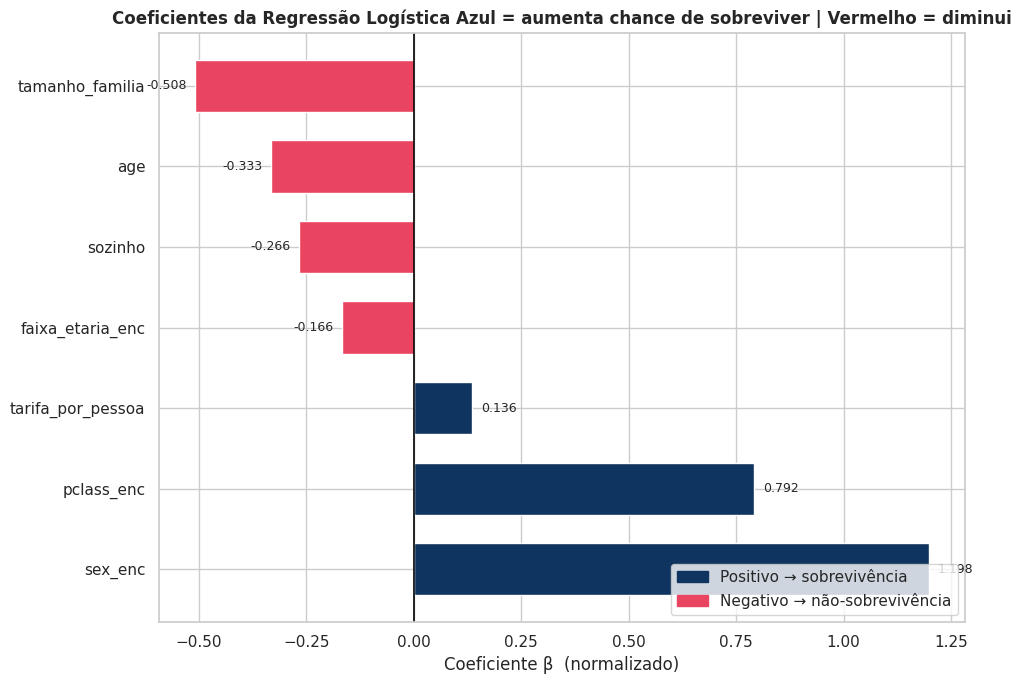

In [10]:
# Gráfico de coeficientes — horizontal divergente
fig, ax = plt.subplots(figsize=(10, 7))

cores = ["#0f3460" if v > 0 else "#e94560"
         for v in coeficientes["coeficiente"]]

barras = ax.barh(coeficientes["feature"],
                  coeficientes["coeficiente"],
                  color=cores, edgecolor="white", height=0.65)

ax.axvline(0, color="black", linewidth=1.2)

# Rótulos nos valores
for b, v in zip(barras, coeficientes["coeficiente"]):
    xpos = v + (0.02 if v >= 0 else -0.02)
    ha   = "left" if v >= 0 else "right"
    ax.text(xpos, b.get_y() + b.get_height()/2,
            f"{v:.3f}", va="center", ha=ha, fontsize=9)

ax.set_xlabel("Coeficiente β  (normalizado)")
ax.set_title("Coeficientes da Regressão Logística "
             "Azul = aumenta chance de sobreviver | Vermelho = diminui",
             fontweight="bold")

patch_pos = mpatches.Patch(color="#0f3460", label="Positivo → sobrevivência")
patch_neg = mpatches.Patch(color="#e94560", label="Negativo → não-sobrevivência")
ax.legend(handles=[patch_pos, patch_neg], loc="lower right")

plt.tight_layout()
plt.savefig("aula06_coeficientes.png", dpi=110, bbox_inches="tight")
plt.show()


In [12]:
# ── GABARITO DA MISSÃO 2 (descomente para ver a interpretação completa) ───────
# print("Gabarito — Interpretação dos coeficientes:")
# print()
# print("Features com coeficiente POSITIVO esperadas:")
# print("  sex_enc (mulher=1), pclass_enc (1a classe=2), titulo_Mrs, titulo_Miss")
# print("  -> Historicamente, mulheres e passageiros de 1a classe sobreviveram mais")
# print()
# print("Features com coeficiente NEGATIVO esperadas:")
# print("  titulo_Mr (homem adulto), pclass=3 (classe baixa)")
# print("  -> Homens adultos de 3a classe tiveram as menores taxas de sobrevivencia")
# print()
# print("Isso confirma o protocolo 'mulheres e criancas primeiro'!")
# print("O modelo nao foi programado com essa regra — ele APRENDEU dos dados.")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 5</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">O Limiar de Decisão — Quando 0,5 Não é a Melhor Escolha</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"A probabilidade é do modelo. A decisão é sua."</p>
    </div>
</div>

### O que é o limiar e por que ele importa

O modelo gera probabilidades. Para transformar probabilidade em classe, precisamos de uma regra:

```
Se P(Sobreviveu) > LIMIAR  →  prevê "Sobreviveu"
Se P(Sobreviveu) ≤ LIMIAR  →  prevê "Não Sobreviveu"
```

O padrão é `LIMIAR = 0.5`, mas esse valor não é sempre o melhor.
Mudar o limiar é uma escolha de negócio, não de algoritmo:

| Situação | Ajuste | Efeito |
|----------|--------|--------|
| Falso Negativo é muito caro (câncer não detectado) | **Baixar** o limiar (ex: 0.3) | Mais alertas → maior Recall, menor Precisão |
| Falso Positivo é muito caro (alarme cirúrgico falso) | **Subir** o limiar (ex: 0.7) | Menos alarmes → maior Precisão, menor Recall |
| Equilíbrio | Encontrar o ponto que maximiza F1 | Trade-off ideal |

Isso é o **trade-off Precisão-Recall**: não dá para maximizar os dois ao mesmo tempo.
O gráfico abaixo torna esse trade-off visual e inequívoco.


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Testando diferentes limiares
limiares   = np.arange(0.1, 0.91, 0.05)
precisoes  = []
recalls    = []
f1s        = []
acuracias  = []

prob_sobrev = modelo_lr.predict_proba(X_teste_sc)[:, 1]

for limiar in limiares:
    y_pred_limiar = (prob_sobrev >= limiar).astype(int)
    precisoes.append(precision_score(y_teste, y_pred_limiar, zero_division=0))
    recalls.append(recall_score(y_teste, y_pred_limiar, zero_division=0))
    f1s.append(f1_score(y_teste, y_pred_limiar, zero_division=0))
    acuracias.append((y_pred_limiar == y_teste.values).mean())

melhor_limiar_f1  = limiares[np.argmax(f1s)]
melhor_limiar_rec = limiares[np.argmax(recalls[:len(recalls)//2])]

print(f"Limiar que maximiza F1-Score:  {melhor_limiar_f1:.2f}  "
      f"(F1={max(f1s):.4f})")
print(f"Limiar padrão (0.5):           F1={f1s[list(limiares).index(min(limiares, key=lambda x: abs(x-0.5)))]:.4f}")


Limiar que maximiza F1-Score:  0.35  (F1=0.7606)
Limiar padrão (0.5):           F1=0.7258


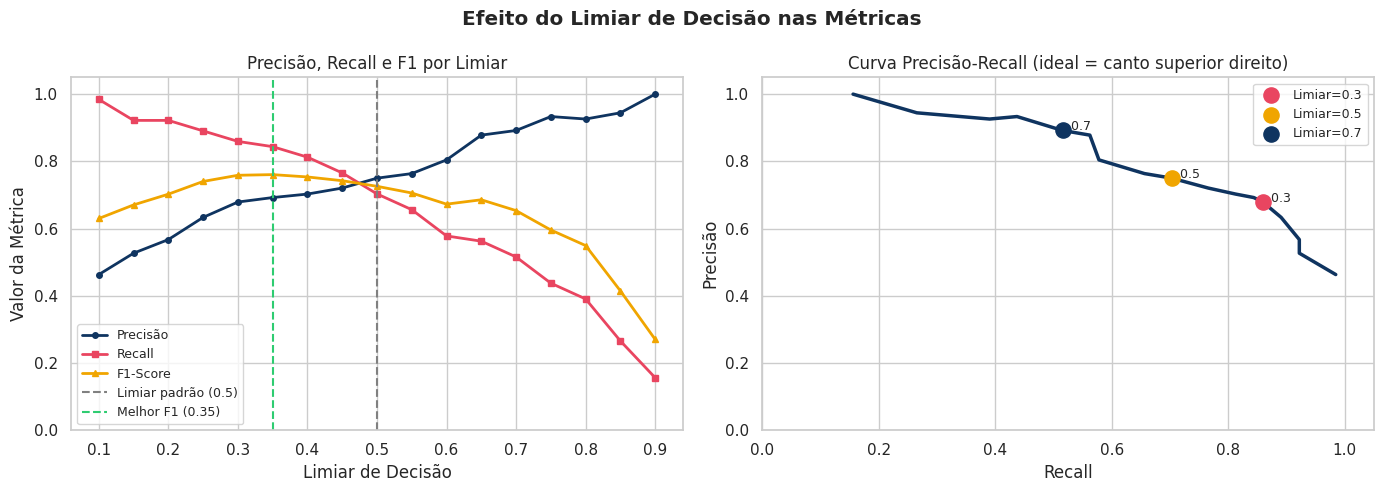

In [14]:
# Curva Precisão-Recall em função do limiar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Efeito do Limiar de Decisão nas Métricas", fontweight="bold")

# Gráfico 1: métricas por limiar
axes[0].plot(limiares, precisoes, "o-", color="#0f3460",
             linewidth=2, markersize=4, label="Precisão")
axes[0].plot(limiares, recalls,   "s-", color="#e94560",
             linewidth=2, markersize=4, label="Recall")
axes[0].plot(limiares, f1s,       "^-", color="#f0a500",
             linewidth=2, markersize=4, label="F1-Score")
axes[0].axvline(0.5, color="gray", linestyle="--",
                linewidth=1.5, label="Limiar padrão (0.5)")
axes[0].axvline(melhor_limiar_f1, color="#2ecc71", linestyle="--",
                linewidth=1.5, label=f"Melhor F1 ({melhor_limiar_f1:.2f})")
axes[0].set_xlabel("Limiar de Decisão")
axes[0].set_ylabel("Valor da Métrica")
axes[0].set_title("Precisão, Recall e F1 por Limiar")
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.05)

# Gráfico 2: curva Precisão-Recall
axes[1].plot(recalls, precisoes, color="#0f3460", linewidth=2.5)
# Marcando limiares específicos
for lim, cor in [(0.3,"#e94560"),(0.5,"#f0a500"),(0.7,"#0f3460")]:
    idx = np.argmin(np.abs(limiares - lim))
    axes[1].scatter(recalls[idx], precisoes[idx], s=120,
                    color=cor, zorder=5, label=f"Limiar={lim:.1f}")
    axes[1].annotate(f"  {lim}", (recalls[idx], precisoes[idx]), fontsize=9)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisão")
axes[1].set_title("Curva Precisão-Recall (ideal = canto superior direito)")
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1.05); axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("aula05_limiar.png", dpi=110, bbox_inches="tight")
plt.show()


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 3 — Usando o limiar que maximiza o F1, aplique a previsão manualmente com <code>(prob_sobrev >= melhor_limiar_f1).astype(int)</code> e compare: (a) o F1 melhora em relação ao limiar 0.5? (b) o Recall mudou? (c) a Precisão mudou? Explique o trade-off que você observou.</span></div>

In [15]:
# ✏️ Complete a análise com o melhor limiar

# y_pred_melhor = (prob_sobrev >= melhor_limiar_f1).astype(int)

# Compare as métricas:
# f1_padrao  = f1_score(y_teste, modelo_lr.predict(X_teste_sc))
# f1_melhor  = f1_score(y_teste, y_pred_melhor)
# rec_padrao = recall_score(y_teste, modelo_lr.predict(X_teste_sc))
# rec_melhor = recall_score(y_teste, y_pred_melhor)

# print(f"Limiar 0.50: F1={f1_padrao:.4f} | Recall={rec_padrao:.4f}")
# print(f"Limiar {melhor_limiar_f1:.2f}: F1={f1_melhor:.4f} | Recall={rec_melhor:.4f}")

print("Complete a comparação acima!")


Complete a comparação acima!


In [16]:
# ── GABARITO DA MISSÃO 3 (descomente para ver) ───────────────────────────────
# y_pred_050    = modelo_lr.predict(X_teste_sc)
# y_pred_melhor = (prob_sobrev >= melhor_limiar_f1).astype(int)
#
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
#
# print(f"COMPARAÇÃO DE LIMIARES")
# print(f"{'Metrica':<12} {'Limiar 0.50':>12} {'Limiar '+str(round(melhor_limiar_f1,2)):>14}")
# print("-" * 42)
# for nome, func in [("Acuracia", accuracy_score),
#                     ("Precisao", precision_score),
#                     ("Recall",   recall_score),
#                     ("F1-Score", f1_score)]:
#     v1 = func(y_teste, y_pred_050)
#     v2 = func(y_teste, y_pred_melhor)
#     diff = v2 - v1
#     sinal = "+" if diff >= 0 else ""
#     print(f"{nome:<12} {v1:>12.4f} {v2:>14.4f}  ({sinal}{diff:.4f})")
#
# print()
# print("Trade-off observado:")
# print("  Baixar o limiar aumenta o Recall (encontra mais sobreviventes reais)")
# print("  mas diminui a Precisao (prevê 'sobreviveu' para alguns que nao sobreviveram)")
# print("  F1 equilibra as duas — e geralmente melhora com o limiar otimo")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 6</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">KNN vs Regressão Logística — Comparação Direta</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Não existe modelo melhor em geral — existe modelo mais adequado para cada problema."</p>
    </div>
</div>

### Como comparar dois modelos corretamente

Comparar só acurácia não basta — especialmente com datasets desbalanceados.
A comparação completa usa as mesmas métricas, nos mesmos dados de teste, para os dois modelos.

Uma métrica especial aparece aqui pela primeira vez: a **AUC-ROC** (Área sob a Curva ROC).

```
Curva ROC: plota Taxa de Verdadeiro Positivo (Recall) vs Taxa de Falso Positivo
           para todos os limiares de decisão possíveis.

AUC = área sob essa curva:
  AUC = 0.5 → modelo aleatório (inútil)
  AUC = 1.0 → modelo perfeito
  AUC > 0.8 → modelo geralmente bom
```

A AUC-ROC é mais robusta que a acurácia porque leva em conta todos os limiares — não só o 0.5.


### Avaliação completa dos dois modelos

Agora que temos dois modelos treinados, vamos compará-los objetivamente
usando as mesmas métricas, nos mesmos dados de teste.


In [17]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, accuracy_score
)



# Previsões de ambos
y_pred_knn  = knn_ref.predict(X_teste_sc)
y_pred_lr   = modelo_lr.predict(X_teste_sc)
y_prob_knn  = knn_ref.predict_proba(X_teste_sc)[:, 1]
y_prob_lr   = modelo_lr.predict_proba(X_teste_sc)[:, 1]

# Tabela de métricas
print("COMPARAÇÃO COMPLETA — KNN (K=7) vs Regressão Logística")
print("=" * 62)
print(f"  {'Métrica':<18} {'KNN (K=7)':>12} {'Reg. Logística':>16}  {'Vencedor':>10}")
print("  " + "-"*60)

metricas = [
    ("Acurácia",  accuracy_score,  {}),
    ("Precisão",  precision_score, {}),
    ("Recall",    recall_score,    {}),
    ("F1-Score",  f1_score,        {}),
    ("AUC-ROC",   roc_auc_score,   {"y_score_knn": y_prob_knn,
                                     "y_score_lr":  y_prob_lr}),
]


for nome, func, extra in metricas:
    if nome == "AUC-ROC":
        v_knn = roc_auc_score(y_teste, extra["y_score_knn"])
        v_lr  = roc_auc_score(y_teste, extra["y_score_lr"])
    else:
        v_knn = func(y_teste, y_pred_knn)
        v_lr  = func(y_teste, y_pred_lr)
    vencedor = "KNN" if v_knn > v_lr else ("Empate" if abs(v_knn - v_lr) < 0.001 else "Log. Reg.")
    print(f"  {nome:<18} {v_knn:>12.4f} {v_lr:>16.4f}  {vencedor:>10}")


COMPARAÇÃO COMPLETA — KNN (K=7) vs Regressão Logística
  Métrica               KNN (K=7)   Reg. Logística    Vencedor
  ------------------------------------------------------------
  Acurácia                 0.8065           0.7806         KNN
  Precisão                 0.7656           0.7500         KNN
  Recall                   0.7656           0.7031         KNN
  F1-Score                 0.7656           0.7258         KNN
  AUC-ROC                  0.8509           0.8553   Log. Reg.


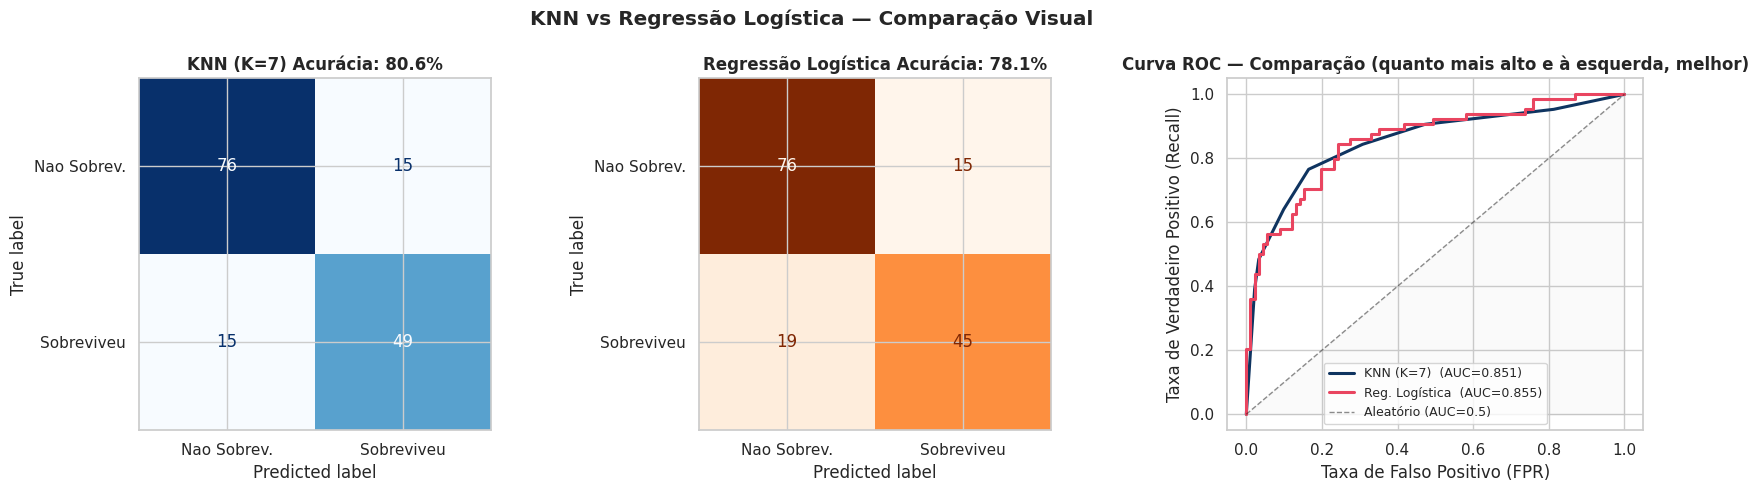

In [18]:
# Visualização completa: matrizes de confusão + curvas ROC
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("KNN vs Regressão Logística — Comparação Visual", fontweight="bold")

# Matriz de confusão — KNN
cm_knn = confusion_matrix(y_teste, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=["Nao Sobrev.", "Sobreviveu"])     .plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"KNN (K=7) Acurácia: {accuracy_score(y_teste, y_pred_knn):.1%}",
                  fontweight="bold")

# Matriz de confusão — Log. Reg.
cm_lr = confusion_matrix(y_teste, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["Nao Sobrev.", "Sobreviveu"])     .plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title(f"Regressão Logística Acurácia: {accuracy_score(y_teste, y_pred_lr):.1%}",
                  fontweight="bold")

# Curvas ROC sobrepostas
for y_prob, nome, cor in [(y_prob_knn, "KNN (K=7)", "#0f3460"),
                           (y_prob_lr,  "Reg. Logística", "#e94560")]:
    fpr, tpr, _ = roc_curve(y_teste, y_prob)
    auc = roc_auc_score(y_teste, y_prob)
    axes[2].plot(fpr, tpr, color=cor, linewidth=2.2, label=f"{nome}  (AUC={auc:.3f})")

axes[2].plot([0,1],[0,1], "k--", linewidth=1, alpha=0.5, label="Aleatório (AUC=0.5)")
axes[2].fill_between([0,1],[0,1], alpha=0.04, color="gray")
axes[2].set_xlabel("Taxa de Falso Positivo (FPR)")
axes[2].set_ylabel("Taxa de Verdadeiro Positivo (Recall)")
axes[2].set_title("Curva ROC — Comparação (quanto mais alto e à esquerda, melhor)",
                  fontweight="bold")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("aula05_comparacao_final.png", dpi=110, bbox_inches="tight")
plt.show()


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 4 — Analise a tabela de métricas e as matrizes de confusão e responda: (a) qual modelo você escolheria para este problema e por quê? (b) os dois modelos erram nos mesmos passageiros ou em passageiros diferentes? (c) existe alguma métrica onde o KNN é claramente superior?</span></div>

In [19]:
# Investigando: os dois modelos erram nos mesmos passageiros?
erros_knn = set(np.where(y_pred_knn != y_teste.values)[0])
erros_lr  = set(np.where(y_pred_lr  != y_teste.values)[0])

erros_comuns      = erros_knn & erros_lr
erros_so_knn      = erros_knn - erros_lr
erros_so_lr       = erros_lr  - erros_knn
acertos_os_dois   = len(y_teste) - len(erros_knn | erros_lr)

print("ANÁLISE DE ERROS COMPARTILHADOS")
print("=" * 45)
print(f"  Total de passageiros no teste:  {len(y_teste)}")
print(f"  Erros do KNN:                   {len(erros_knn)}")
print(f"  Erros da Log. Reg.:             {len(erros_lr)}")
print()
print(f"  Erros COMUNS (ambos erram):     {len(erros_comuns)}")
print(f"  Só KNN erra:                    {len(erros_so_knn)}")
print(f"  Só Log. Reg. erra:              {len(erros_so_lr)}")
print(f"  Ambos acertam:                  {acertos_os_dois}")
print()
print("💡 Passageiros onde apenas UM modelo erra são os mais 'difíceis'.")
print("   Combinar modelos (ensemble) pode aproveitar os pontos fortes de cada um.")
print("   Esse será um tema futuro no curso!")


ANÁLISE DE ERROS COMPARTILHADOS
  Total de passageiros no teste:  155
  Erros do KNN:                   30
  Erros da Log. Reg.:             34

  Erros COMUNS (ambos erram):     21
  Só KNN erra:                    9
  Só Log. Reg. erra:              13
  Ambos acertam:                  112

💡 Passageiros onde apenas UM modelo erra são os mais 'difíceis'.
   Combinar modelos (ensemble) pode aproveitar os pontos fortes de cada um.
   Esse será um tema futuro no curso!


In [20]:
# ── GABARITO DA MISSÃO 4 (descomente para ver) ───────────────────────────────
# print("Gabarito — Análise comparativa:")
# print()
# print("(a) Qual modelo escolher?")
# print("    Depende da prioridade:")
# print("    - Se Recall importa mais (encontrar todos os sobreviventes):")
# print("      observe qual tem recall maior na tabela de métricas")
# print("    - Se interpretabilidade importa (explicar a decisão):")
# print("      Log. Reg. é claramente superior — os coeficientes têm significado")
# print("    - Se apenas acurácia/F1 importa:")
# print("      compare os valores e escolha o maior")
# print()
# print("(b) Os modelos erram nos mesmos passageiros?")
# print(f"    {len(erros_comuns)} passageiros são difíceis para ambos.")
# print(f"    {len(erros_so_knn)} são fáceis para Log. Reg. mas difíceis para KNN.")
# print(f"    {len(erros_so_lr)} são fáceis para KNN mas difíceis para Log. Reg.")
# print("    Isso sugere que os modelos capturam padrões diferentes!")
# print()
# print("(c) KNN pode ser superior em:")
# print("    - Capturar fronteiras de decisão complexas e não-lineares")
# print("    - Situações com poucos dados e fronteiras irregulares")
# print("    Log. Reg. tende a ser superior em:")
# print("    - Datasets maiores e mais lineares")
# print("    - Quando interpretabilidade é requisito")


---

## Tabela Comparativa — Quando Usar Cada Algoritmo

| Critério | KNN | Regressão Logística |
|----------|-----|---------------------|
| **Interpretabilidade** | Baixa | Alta — coeficientes explicam as decisões |
| **Velocidade de treino** | Instantâneo | Rápido |
| **Velocidade de predição** | Lento (calcula distâncias) | Muito rápido |
| **Produz probabilidades** | Sim (estimadas) | Sim (diretamente da sigmoide) |
| **Fronteiras de decisão** | Qualquer forma | Apenas lineares |
| **Escalabilidade** | Ruim com datasets grandes | Boa |
| **Normalização obrigatória** | Sim | Recomendada |
| **Hiperparâmetro principal** | K (número de vizinhos) | C (regularização) |

<div style="background:#e8d5f5; border-left:5px solid #5b2c8d; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#5b2c8d;">💡 </strong><span style="color:#5b2c8d;">Regra prática: <strong>sempre comece com Regressão Logística como baseline</strong>. Se o problema for mais complexo e não-linear, e você tiver dados suficientes, experimente modelos mais complexos. Se não superarem a Regressão Logística por uma margem significativa, ela já é sua resposta.</span></div>

---

## Checklist — O que você sabe fazer agora

| Habilidade | Praticada hoje? |
|------------|----------------|
| Explicar por que regressão linear falha na classificação | ☐ |
| Desenhar e interpretar a curva sigmoide | ☐ |
| Calcular P(Y=1) manualmente com a fórmula da sigmoide | ☐ |
| Usar `LogisticRegression.fit()`, `.predict()` e `.predict_proba()` | ☐ |
| Interpretar coeficientes positivos e negativos | ☐ |
| Ajustar o limiar de decisão para diferentes objetivos | ☐ |
| Comparar dois modelos com métricas e curva ROC | ☐ |
| Identificar se dois modelos erram nos mesmos exemplos | ☐ |

---


---

## Checklist — O que você sabe fazer agora

| Habilidade | Praticada hoje? |
|------------|----------------|
| Explicar por que regressão linear falha na classificação | ☐ |
| Desenhar e interpretar a curva sigmoide | ☐ |
| Calcular P(Y=1) manualmente com a fórmula da sigmoide | ☐ |
| Usar `LogisticRegression.fit()`, `.predict()` e `.predict_proba()` | ☐ |
| Interpretar coeficientes positivos e negativos | ☐ |
| Ajustar o limiar de decisão para diferentes objetivos | ☐ |
| Comparar dois modelos com métricas e curva ROC | ☐ |
| Identificar se dois modelos erram nos mesmos exemplos | ☐ |

---

## Reflexão final

<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#a04000;">Escreva em suas próprias palavras:</strong>
<span style="color:#a04000;"> (1) qual é a diferença fundamental entre KNN e Regressão Logística?, (2) quando você escolheria Regressão Logística em vez de KNN num projeto real?, e (3) o que você entende por "limiar de decisão" e por que ele importa?</span>
</div>

**Minha reflexão:**

1. Diferença fundamental KNN vs Reg. Logística: *...*

2. Escolheria Reg. Logística quando: *...*

3. Limiar de decisão é: *...* — importa porque: *...*

---

<div style="background:#d4edda; border-left:5px solid #155724; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#155724;">Parabéns por concluir a Aula 05!</strong><br>
<span style="color:#155724;">Você tem agora dois modelos no seu repertório — KNN e Regressão Logística. A Regressão Logística vai ser sua baseline para todo projeto de classificação daqui pra frente. Qualquer modelo mais complexo precisa superar ela para justificar a complexidade extra.</span>
</div>
